# Site Modelling

# Spin Hamiltonian Modelling

In [12]:
import numpy as np
import matplotlib.pyplot as plt

import spin_package.qil_SpinHamiltonian.spin_hamiltonian as spin
import spin_package.qil_SpinHamiltonian.spin_hamiltonian as search
h=spin.h

In [14]:
Espin = 1/2
Ispin = 1/2

# Natural units of the program are GHz, T and radians so conversions must be made
M = np.matrix(np.diag([2.86,3.05,11.56]))*10*1E6*h
Q = np.matrix(np.diag([-0.5624,0.5624,4.4450]))*1E6*h
alpha,beta,gamma = np.array([-99.8,55.8,-40])*np.pi/180

# No convention for rotation is specified in the data source, but ZYZ is typical
M = spin.tensorRotation(M,[alpha,beta,gamma],conv='ZYZ')
Q = spin.tensorRotation(Q,[alpha,beta,gamma],conv='ZYZ')

# Instantiates the class and sets up dimensions and spin matrices
ground = spin.cSpinHamiltonian(Espin,Ispin)

# Pass these matrices to the class
ground.setM(M)

# This will calculate and store the interaction in our static hamiltonian
ground.quadrupoleInteraction(Q)
print(ground.H.shape) #Access the static hamiltonian it big so lets just print its shape

(4, 4)


In [36]:
groundI = spin.hamilFromYAML('./ion_params/Pr_YSO.yml', IOveride = 3/2)
# We can also change the spin values if we want to look at other isotopes
# Let's pretend Pr has a stable spin 3/2 isotope
groundN = spin.hamilFromYAML('./ion_params/Pr_YSO.yml', IOveride = 1/2)

{'Spin': {'Espin': '0', 'Ispin': '5/2'}, 'Quadrupole': {'Q': 'np.matrix(np.diag([-0.5624,0.5624,4.4450]))*1E6*h', 'Q_rot': 'np.array([-94,58.1,-20.7])*np.pi/180'}, 'N_Zeeman': {'M': 'np.matrix(np.diag([2.86,3.05,11.56]))*10*1E6*h', 'M_rot': 'np.array([-99.7,55.7,-40])*np.pi/180'}}
{'Spin': {'Espin': '0', 'Ispin': '5/2'}, 'Quadrupole': {'Q': 'np.matrix(np.diag([-0.5624,0.5624,4.4450]))*1E6*h', 'Q_rot': 'np.array([-94,58.1,-20.7])*np.pi/180'}, 'N_Zeeman': {'M': 'np.matrix(np.diag([2.86,3.05,11.56]))*10*1E6*h', 'M_rot': 'np.array([-99.7,55.7,-40])*np.pi/180'}}


(200, 4)
(200, 16)


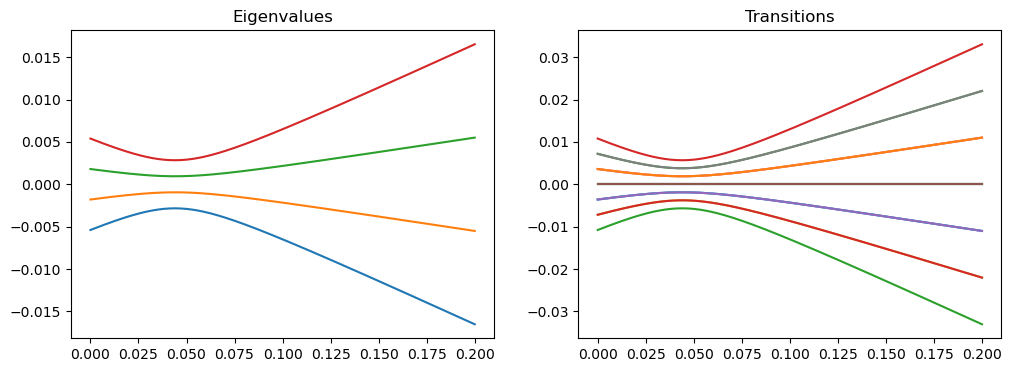

In [37]:
# Generate a set of fields from zero to 100mT
Bz = np.linspace(0,200*1E-3,200)

# Unit vector along z
uvec = np.matrix([0,0,1]).T

# Convert it to a vector along the our axis
B = uvec*Bz

# If we are doing simple things dynamicH suffices
    # It automatically adds the static hamiltonian if static=True
H = groundI.dynamicH(B)

# This actually conceals a few important things so to write it out in full
    # ground.H contains our static hamiltonian, 
    # it doesn't know about the dimension of the magnetic field
    # Using np.newaxis we can increase the dimension to match the zeeman data
H = np.array(groundI.H)[np.newaxis,...] - groundI.nuclearZeeman(B)

# Get the eigenvalues F and Vectors
F,V = groundI.getEigFreq(H)

fig, (ax0, ax1) = plt.subplots(1, 2, figsize = (12, 4))
# Dimension convention makes is to aid such plotting
ax0.plot(Bz, F)
print(np.shape(F))
ax0.set_title('Eigenvalues')

# Calculate the transitions, noting that our transitions always lie across axis 1
T = spin.eachElemFunc(F,F,axis = 1)
ax1.plot(Bz,T)
print(np.shape(T))
ax1.set_title('Transitions')
plt.show()

# Test Area

$H = \mu_B \times B \times g \times S$

In [38]:
import qutip as qt

In [ ]:
dim = 2
muB = 9.2740100657e-24 # J/T
eye = qt.identity(dim)
sz = qt.sigmaz() # Pauli-Z matrix [2x2]
# Bz = np.linspace(0, 200 * 1E-3, 200) # array of magnetic fields

J = 
dim = 
S = qt.tensor(sz, eye)
B = [0, 0, 8] # Example field in z
g = qt.qdiags([2, 2, 1], 0) # Example g tensor on axial site


In [73]:
g = np.diag([2, 2, 1])
g

array([[2, 0, 0],
       [0, 2, 0],
       [0, 0, 1]])

In [ ]:
eZeeman = 

Quantum object: dims=[[2, 2], [1, 2]], shape=(4, 2), type='oper', dtype=Dia, isherm=False
Qobj data =
[[2. 0.]
 [0. 2.]
 [2. 0.]
 [0. 2.]]

# 0 g Orientation

In [ ]:
Espin = 1/2

# Ensemble-Scale Pair Site